In [1]:
# Spam datasetini KaggleHub ile indiriyoruz

import kagglehub

dataset_path = kagglehub.dataset_download(
    "uciml/sms-spam-collection-dataset"
)

print(dataset_path)

/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset


In [2]:
# Dataset dosyalarını kontrol ediyoruz

import os

print(os.listdir(dataset_path))

['spam.csv']


In [4]:
# Dataseti uygun encoding ile yüklüyoruz

import pandas as pd

df = pd.read_csv(
    dataset_path + "/spam.csv",
    encoding="latin-1"
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Dataseti yüklüyoruz

import pandas as pd

df = pd.read_csv(dataset_path + "/spam.csv")

df.head()

UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 606-607: invalid continuation byte

In [6]:
# Veri yapısını inceliyoruz

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
# Eksik veri kontrolü yapıyoruz

df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [8]:
# Gereksiz sütunları siliyoruz

df = df[["v1", "v2"]]

df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# Label encoding yapıyoruz

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# X ve y oluşturuyoruz

X = df["message"]

y = df["label"]

In [11]:
# Metinleri sayısal veriye dönüştürüyoruz

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [12]:
# Train test split yapıyoruz

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
# Naive Bayes modelini kuruyoruz

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.9623318385650225


In [14]:
# Confusion Matrix oluşturuyoruz

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, nb_pred)

array([[965,   0],
       [ 42, 108]])

In [15]:
# Classification Report oluşturuyoruz

from sklearn.metrics import classification_report

print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



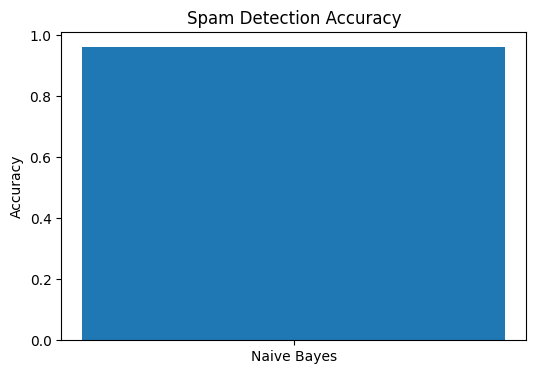

In [16]:
# Accuracy grafiği oluşturuyoruz

import matplotlib.pyplot as plt

models = ["Naive Bayes"]

scores = [nb_acc]

plt.figure(figsize=(6,4))

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.title("Spam Detection Accuracy")

plt.show()

# Spam Email Detection NLP Project Sonuçları

Bu projede SMS Spam Collection veri seti kullanılarak spam mesaj tespiti gerçekleştirilmiştir.

Proje kapsamında:

- Veri temizleme işlemleri yapılmıştır.
- Metin verileri TF-IDF yöntemi ile sayısal hale dönüştürülmüştür.
- Train/Test ayrımı gerçekleştirilmiştir.

Projede:
- Naive Bayes algoritması

kullanılmıştır.

Model performansı accuracy skoru ile değerlendirilmiştir.

Ayrıca:
- Confusion Matrix
- Classification Report
- Accuracy grafiği

oluşturulmuştur.

Bu proje ile:
- NLP
- Text Classification
- TF-IDF
- Spam Detection
- Machine Learning

konuları uygulamalı olarak gerçekleştirilmiştir.